# Diffusion model to generate new images


In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 23.4 MB/s eta 0:00:00


In [ ]:
!pip install diffusers

In [ ]:
!pip install torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 125.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 100.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 113.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvj

Installing packages

In [20]:
import torch
import torchvision
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from diffusers import DDPMScheduler, UNet2DModel
import matplotlib.pyplot as plt
import optuna

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
!mkdir -p /content/GitDiff


In [16]:
%cd /content/GitDiff


/content/GitDiff


In [17]:
!git init


hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/GitDiff/.git/


In [51]:
!git add .


In [52]:
!git commit -m "noise exploration + first hyperparameter tuning"


On branch master
nothing to commit, working tree clean


In [44]:
!git remote add origin https://github.com/colineberthe/Diffusion-model-image-generation.git

error: remote origin already exists.


In [59]:
!git push --set-upstream main


fatal: 'main' does not appear to be a git repository
fatal: Could not read from remote repository.

Please make sure you have the correct access rights
and the repository exists.


In [56]:
!git status

On branch master
nothing to commit, working tree clean


### Defining the Diffusion Trainer class

In [35]:


class DiffusionTrainer:
    """
    A class encapsulating the training and sampling procedures of a Denoising Diffusion Probabilistic Model (DDPM).

    This class implements:
    - Forward diffusion process using a noise scheduler (q(x_t | x_0))
    - Training of a UNet neural network to predict added noise at any timestep
    - Sampling procedure from pure noise using the learned denoising model

    Attributes:
        model: The UNet2DModel that predicts noise from noised inputs
        noise_scheduler: A scheduler managing noise levels at each timestep
        optimizer: Optimizer for model training
        device: Device on which model and data are placed
    """
    def __init__(self, device, scheduler_kwargs=None, lr=1e-4):
        """
        Initialize the trainer with model, scheduler, and optimizer.

        Args:
            device: Torch device ("cuda" or "cpu")
            scheduler_kwargs: Dictionary of keyword arguments to customize the DDPMScheduler.
                Accepts keys such as:
                    - beta_schedule (str): e.g., "linear", "scaled_linear", "squaredcos_cap_v2"
                    - beta_start (float): Initial beta value for linear schedules
                    - beta_end (float): Final beta value for linear schedules
                    - num_train_timesteps (int): Total number of diffusion steps
            lr: Learning rate for the optimizer
        """
        self.device = device
        self.dir = dir
        self.model = UNet2DModel(
            sample_size=28,
            in_channels=1,
            out_channels=1,
            layers_per_block=2,
            block_out_channels=(32, 64, 128),
            down_block_types=("DownBlock2D", "AttnDownBlock2D", "AttnDownBlock2D"),
            up_block_types=("AttnUpBlock2D", "AttnUpBlock2D", "UpBlock2D"),
        ).to(device)

        if scheduler_kwargs is None:
            scheduler_kwargs = {
                "beta_schedule": "squaredcos_cap_v2",
                "num_train_timesteps": 1000
            }

        self.noise_scheduler = DDPMScheduler(**scheduler_kwargs)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

    def train(self, dataloader, epochs):
        """
        Train the diffusion model to predict noise added during forward process.

        Args:
            dataloader: DataLoader providing training batches of clean images
            epochs: Number of passes through the training dataset
        """
        self.model.train()
        losses = []
        for epoch in range(epochs):
            epoch_losses = []
            for batch, _ in dataloader:
                batch = batch.to(self.device)
                timesteps = torch.randint(
                    0, self.noise_scheduler.num_train_timesteps,
                    (batch.size(0),), device=self.device
                ).long()

                noise = torch.randn_like(batch)
                noisy_batch = self.noise_scheduler.add_noise(batch, noise, timesteps)

                noise_pred = self.model(noisy_batch, timesteps).sample
                loss = nn.functional.mse_loss(noise_pred, noise)

                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

                epoch_losses.append(loss.item())

            avg_loss = sum(epoch_losses) / len(epoch_losses)
            losses.append(avg_loss)
            print(f"Epoch {epoch+1}/{epochs}, Avg Loss: {avg_loss:.5f}")

            torch.save(
                self.model.state_dict(),
                f"{epoch+1}ep_{self.noise_scheduler.config.beta_schedule}_number_generator.pt"
            )

        plt.figure(figsize=(10, 5))
        plt.plot(losses)
        plt.title("Training Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.show()

    def sample(self, num_samples=16):
        """
        Generate images by reversing the diffusion process starting from noise.

        Args:
            num_samples: Number of images to generate

        Returns:
            A batch of generated images scaled to [0, 1] for visualization
        """
        self.model.eval()
        img = torch.randn(num_samples, 1, 28, 28, device=self.device)
        for t in self.noise_scheduler.timesteps:
            with torch.no_grad():
                pred_noise = self.model(img, t).sample
            img = self.noise_scheduler.step(pred_noise, t, img).prev_sample

        img = (img.clamp(-1, 1) + 1) / 2
        return img


def objective(trial):
    """
    Optuna objective function for hyperparameter tuning of the DDPM.
    Tunes the beta_start, beta_end, and learning rate.
    """
    scheduler_params = {
        "beta_schedule": trial.suggest_categorical("beta_schedule", ["linear", "scaled_linear", "squaredcos_cap_v2", "sigmoid"]),
        "beta_start": trial.suggest_float("beta_start", 1e-5, 1e-3, log=True),
        "beta_end": trial.suggest_float("beta_end", 0.01, 0.2),
        "num_train_timesteps": 1000
    }
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)

    trainer = DiffusionTrainer(device=device, scheduler_kwargs=scheduler_params, lr=lr)
    trainer.model.train()

    losses = []
    for batch, _ in train_dataloader:
        batch = batch.to(device)
        timesteps = torch.randint(0, trainer.noise_scheduler.num_train_timesteps, (batch.size(0),), device=device).long()
        noise = torch.randn_like(batch)
        noisy_batch = trainer.noise_scheduler.add_noise(batch, noise, timesteps)
        noise_pred = trainer.model(noisy_batch, timesteps).sample
        loss = nn.functional.mse_loss(noise_pred, noise)

        trainer.optimizer.zero_grad()
        loss.backward()
        trainer.optimizer.step()

        losses.append(loss.item())
        if len(losses) > 10:
            break

    return sum(losses) / len(losses)

def plot_noise(scheduler_kwargs=None):
    if scheduler_kwargs is None:
        scheduler_kwargs = {}
    noise_scheduler = DDPMScheduler(**scheduler_kwargs)
    schedule_name = scheduler_kwargs.get("beta_schedule", "Unknown Schedule")

    plt.plot(noise_scheduler.alphas_cumprod.cpu() ** 0.5, label=r"$\sqrt{\bar{\alpha}_t}$")

    plt.plot((1 - noise_scheduler.alphas_cumprod.cpu()) ** 0.5, label=r"$\sqrt{1 - \bar{\alpha}_t}$")

    plt.xlabel('Time step')
    plt.ylabel('Value')
    if schedule_name:
        plt.title(f'Noise Scheduler Parameters with {schedule_name}')
    else:
        plt.title('Noise Scheduler Parameters')
    plt.legend(fontsize="x-large")
    plt.show()

def plot_generated_samples(samples, num_samples=16, title="Generated Samples"):
    """
    Plot a grid of generated samples.

    Args:
        samples: A batch of generated images as a torch tensor.
        num_samples: Number of samples to plot.
        title: Title for the plot.
    """
    grid = torchvision.utils.make_grid(samples.cpu(), nrow=4)

    plt.figure(figsize=(6, 6))
    plt.title("Generated Samples")
    plt.imshow(grid[0], cmap='Greys')
    plt.axis('off')
    plt.show()
import torchvision.transforms as T

def visualize_forward_diffusion(trainer, dataset, schedule_name, num_steps=8):
    """
    Visualize the forward diffusion process for an example image from the dataset.

    Args:
        trainer: A DiffusionTrainer instance (already configured with a specific noise schedule).
        dataset: The dataset to draw an example image from.
        schedule_name: The name of the noise schedule (for the plot title).
        num_steps: Number of timesteps to visualize (evenly spaced).
    """
    trainer.model.eval()
    noise_scheduler = trainer.noise_scheduler


    img, _ = dataset[0]
    img = img.unsqueeze(0).to(trainer.device)


    timesteps = torch.linspace(0, noise_scheduler.config.num_train_timesteps - 1, num_steps).long().to(trainer.device)


    plt.figure(figsize=(2.5 * num_steps, 2.5))

    for i, t in enumerate(timesteps):
        noise = torch.randn_like(img)
        noised_img = noise_scheduler.add_noise(img, noise, t)

        noised_img_vis = (noised_img[0].detach().cpu().clamp(-1, 1) + 1) / 2
        plt.subplot(1, num_steps, i + 1)
        if noised_img_vis.shape[0] == 1:
            plt.imshow(noised_img_vis[0], cmap="gray")
        else:
            plt.imshow(noised_img_vis.permute(1, 2, 0))
        plt.title(f"t={t.item()}")
        plt.axis("off")

    plt.suptitle(f"Forward Process — {schedule_name} Schedule", fontsize=16)
    plt.show()




Setting the environment and loading the data set

In [29]:
dir = "content/GitDiff/"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

dataset = torchvision.datasets.MNIST(
    root="mnist/", train=True, download=True,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Lambda(lambda x: x * 2.0 - 1.0),
    ])
)
train_dataloader = DataLoader(dataset, batch_size=128, shuffle=True)



Using device: cuda


### Exploring different noise schedules

In [24]:
beta_schedules = ["linear", "scaled_linear", "squaredcos_cap_v2", "sigmoid"]

#### Focusing on the forward pass

Training with linear schedule


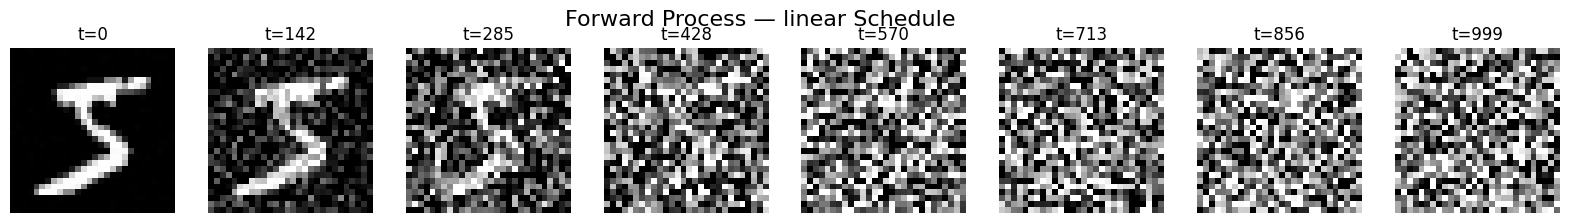

Training with scaled_linear schedule


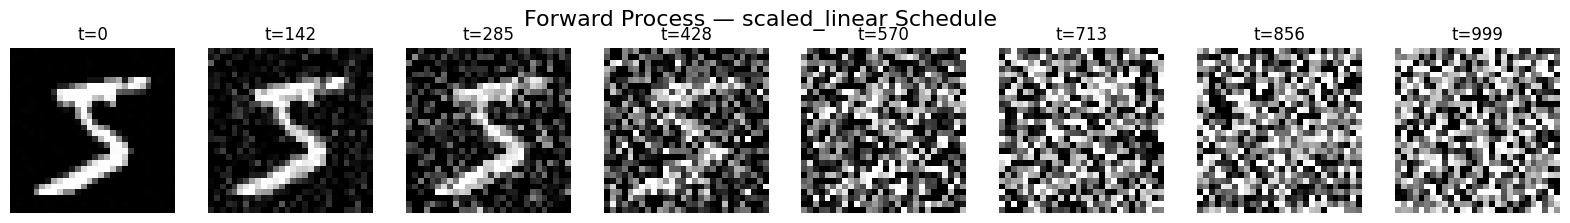

Training with squaredcos_cap_v2 schedule


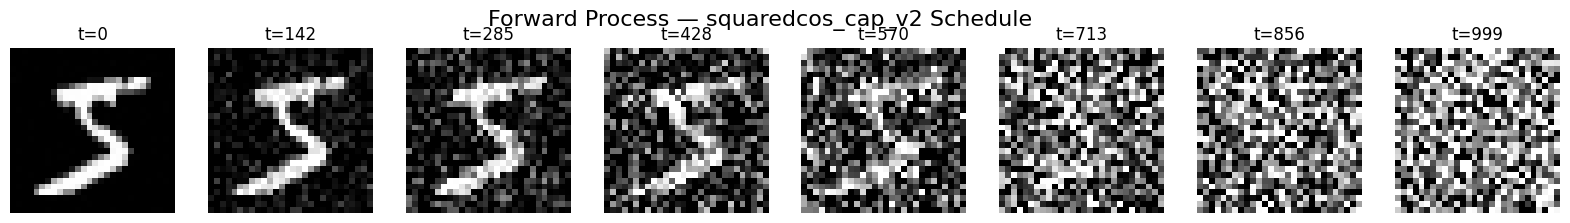

Training with sigmoid schedule


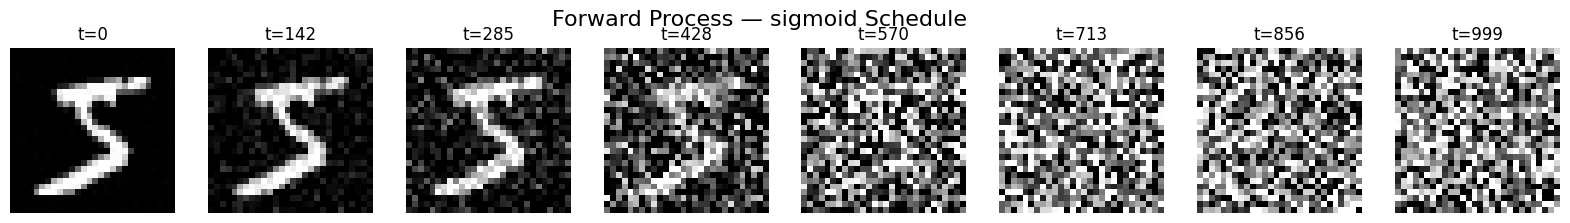

In [27]:
for schedule in beta_schedules:
  print(f"Training with {schedule} schedule")
  scheduler_kwargs = {
        "beta_schedule": schedule,
        "num_train_timesteps": 1000
    }
  trainer = DiffusionTrainer(device=device, scheduler_kwargs=scheduler_kwargs, lr=1e-4)
  visualize_forward_diffusion(trainer, dataset, schedule_name=trainer.noise_scheduler.config.beta_schedule, num_steps=8)

#### Generating images using different schedules

Training with linear schedule


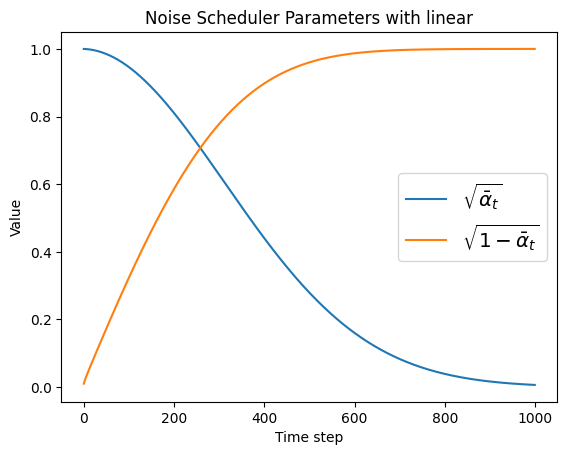

Epoch 1/10, Avg Loss: 0.09336
Epoch 2/10, Avg Loss: 0.04002
Epoch 3/10, Avg Loss: 0.03396
Epoch 4/10, Avg Loss: 0.03124
Epoch 5/10, Avg Loss: 0.02958
Epoch 6/10, Avg Loss: 0.02843
Epoch 7/10, Avg Loss: 0.02710
Epoch 8/10, Avg Loss: 0.02654
Epoch 9/10, Avg Loss: 0.02586
Epoch 10/10, Avg Loss: 0.02546


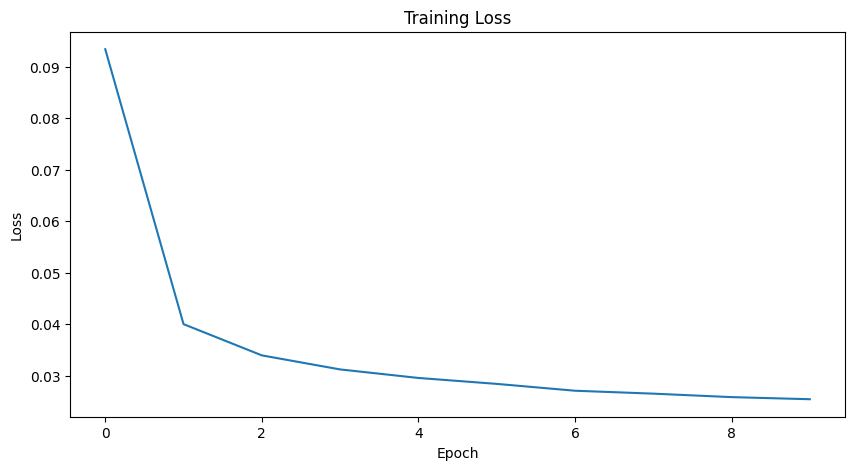

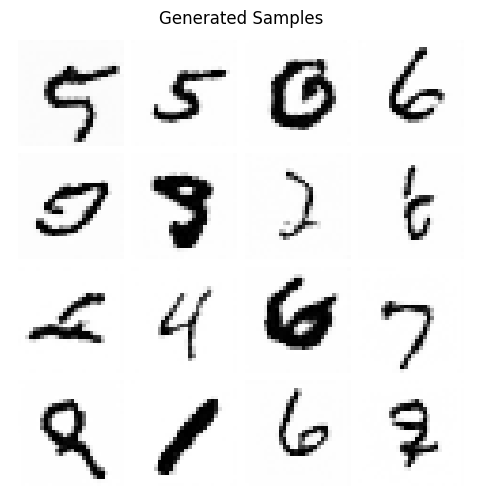

Training with scaled_linear schedule


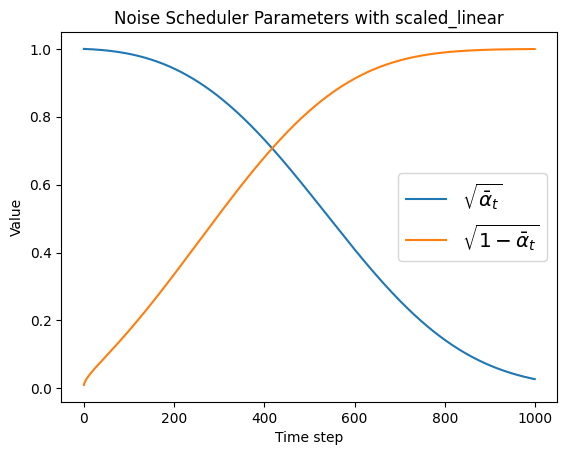

Epoch 1/10, Avg Loss: 0.12144
Epoch 2/10, Avg Loss: 0.05643
Epoch 3/10, Avg Loss: 0.04860
Epoch 4/10, Avg Loss: 0.04476
Epoch 5/10, Avg Loss: 0.04327
Epoch 6/10, Avg Loss: 0.04177
Epoch 7/10, Avg Loss: 0.04055
Epoch 8/10, Avg Loss: 0.04005
Epoch 9/10, Avg Loss: 0.03914
Epoch 10/10, Avg Loss: 0.03887


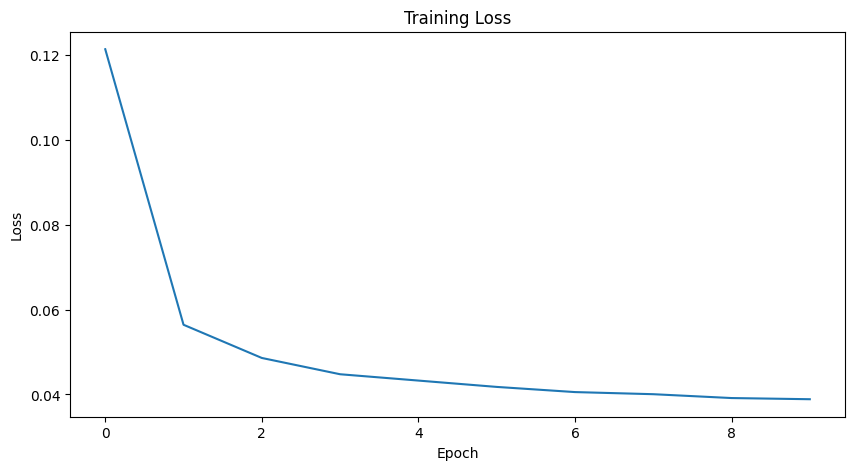

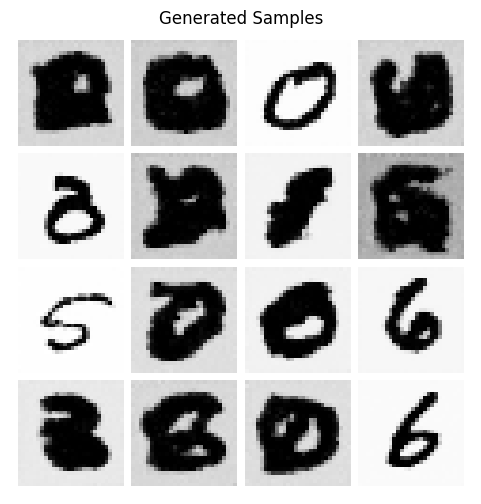

Training with squaredcos_cap_v2 schedule


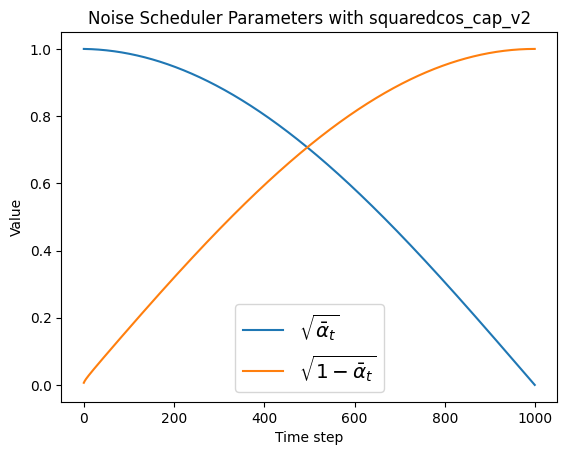

Epoch 1/10, Avg Loss: 0.13501
Epoch 2/10, Avg Loss: 0.06355
Epoch 3/10, Avg Loss: 0.05489
Epoch 4/10, Avg Loss: 0.05062
Epoch 5/10, Avg Loss: 0.04855
Epoch 6/10, Avg Loss: 0.04692
Epoch 7/10, Avg Loss: 0.04569
Epoch 8/10, Avg Loss: 0.04505
Epoch 9/10, Avg Loss: 0.04403
Epoch 10/10, Avg Loss: 0.04329


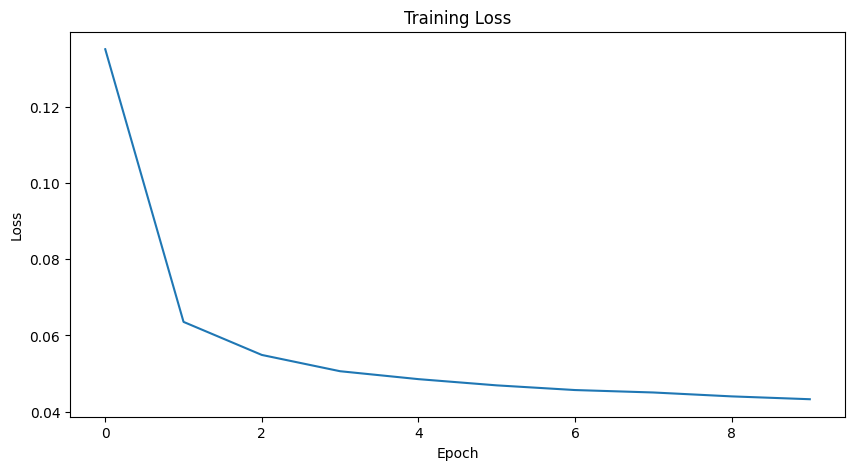

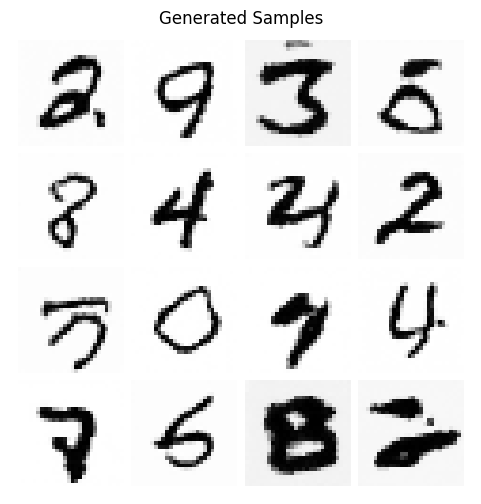

Training with sigmoid schedule


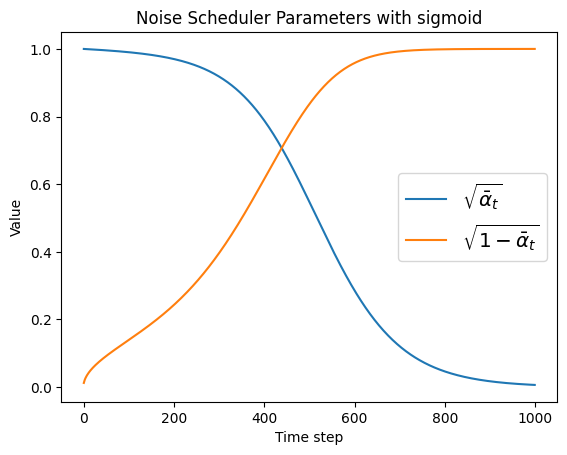

Epoch 1/10, Avg Loss: 0.12441
Epoch 2/10, Avg Loss: 0.05788
Epoch 3/10, Avg Loss: 0.05019
Epoch 4/10, Avg Loss: 0.04664
Epoch 5/10, Avg Loss: 0.04439
Epoch 6/10, Avg Loss: 0.04260
Epoch 7/10, Avg Loss: 0.04200
Epoch 8/10, Avg Loss: 0.04140
Epoch 9/10, Avg Loss: 0.04011
Epoch 10/10, Avg Loss: 0.04005


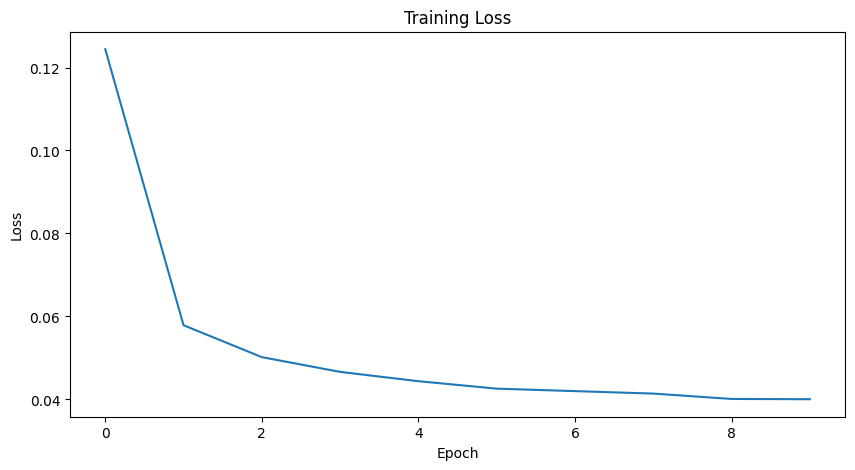

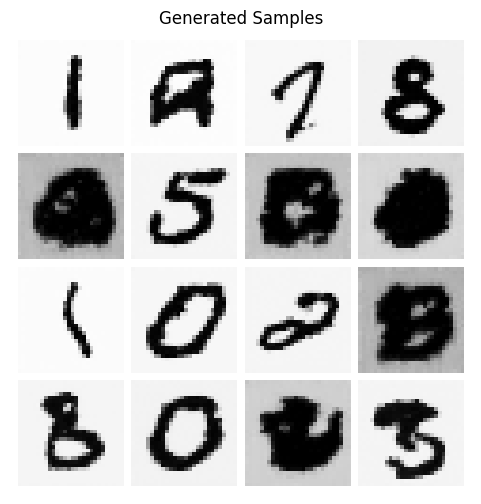

In [33]:
for schedule in beta_schedules:
    print(f"Training with {schedule} schedule")

    scheduler_kwargs = {
        "beta_schedule": schedule,
        "num_train_timesteps": 1000
    }

    plot_noise(scheduler_kwargs)

    trainer = DiffusionTrainer(device=device, scheduler_kwargs=scheduler_kwargs, lr=1e-4)

    trainer.train(train_dataloader, epochs=10)

    plot_generated_samples(trainer.sample(num_samples=16), title=f"Generated Samples with {schedule} schedule")


### Hyperparameter tuning

In [36]:
# Run hyperparameter tuning with Optuna
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)
torch.save(
                study.best_params,
                f"ddpm_best_parameters_20trials_1.pt"
            )
print("Best hyperparameters:", study.best_params)


[I 2025-06-10 15:11:00,560] A new study created in memory with name: no-name-895b16ab-e6a9-46f4-8745-cd7deeff6910
[I 2025-06-10 15:11:03,423] Trial 0 finished with value: 0.4202061512253501 and parameters: {'beta_schedule': 'squaredcos_cap_v2', 'beta_start': 0.00030304214733664793, 'beta_end': 0.054774895658930414, 'lr': 0.0004595234722866221}. Best is trial 0 with value: 0.4202061512253501.
[I 2025-06-10 15:11:06,239] Trial 1 finished with value: 0.7170530313795264 and parameters: {'beta_schedule': 'squaredcos_cap_v2', 'beta_start': 0.0001959238328879398, 'beta_end': 0.05068491863569376, 'lr': 0.00010991487062941662}. Best is trial 0 with value: 0.4202061512253501.
[I 2025-06-10 15:11:09,048] Trial 2 finished with value: 0.4698909277265722 and parameters: {'beta_schedule': 'scaled_linear', 'beta_start': 1.1320978365153585e-05, 'beta_end': 0.1333155223056692, 'lr': 0.0003123556458151648}. Best is trial 0 with value: 0.4202061512253501.
[I 2025-06-10 15:11:11,862] Trial 3 finished with 

Best hyperparameters: {'beta_schedule': 'linear', 'beta_start': 0.00025879654622918666, 'beta_end': 0.14941883972205097, 'lr': 0.0009497456176409442}


In [ ]:
file_path = "/content/drive/MyDrive/Diffusion/ddpm_best_parameters_20trials.pt"

best_params = torch.load(file_path)

print("Best parameters:", best_params)


Best parameters: {'beta_schedule': 'squaredcos_cap_v2', 'beta_start': 0.00015064770460850388, 'beta_end': 0.07062676916106778, 'lr': 0.0008923503813371513}


#### Generating images with set hyperparameter

/usr/local/lib/python3.11/dist-packages/diffusers/configuration_utils.py:141: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


Epoch 1/20, Avg Loss: 0.07629
Epoch 2/20, Avg Loss: 0.04868
Epoch 3/20, Avg Loss: 0.04542
Epoch 4/20, Avg Loss: 0.04326
Epoch 5/20, Avg Loss: 0.04259
Epoch 6/20, Avg Loss: 0.04148
Epoch 7/20, Avg Loss: 0.04073
Epoch 8/20, Avg Loss: 0.04052
Epoch 9/20, Avg Loss: 0.03994
Epoch 10/20, Avg Loss: 0.03967
Epoch 11/20, Avg Loss: 0.03937
Epoch 12/20, Avg Loss: 0.03915
Epoch 13/20, Avg Loss: 0.03890
Epoch 14/20, Avg Loss: 0.03863
Epoch 15/20, Avg Loss: 0.03845
Epoch 16/20, Avg Loss: 0.03837
Epoch 17/20, Avg Loss: 0.03834
Epoch 18/20, Avg Loss: 0.03841
Epoch 19/20, Avg Loss: 0.03841
Epoch 20/20, Avg Loss: 0.03824


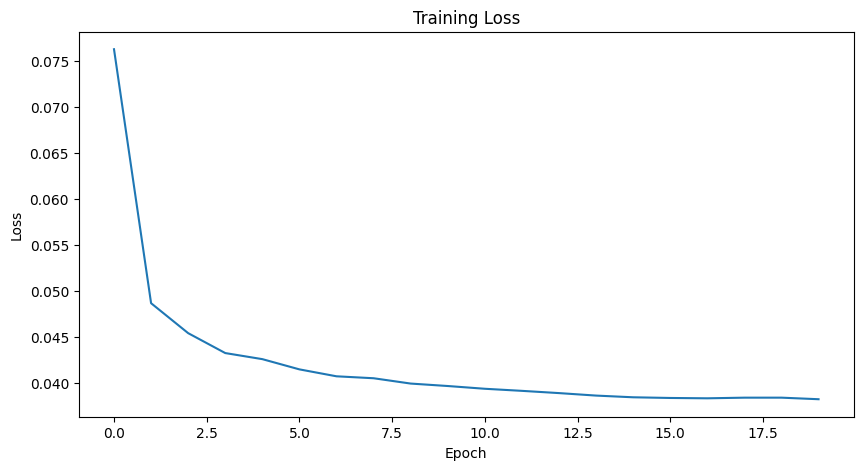

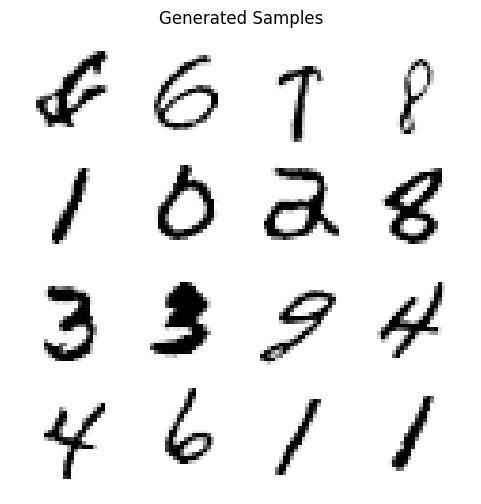

In [ ]:

trainer = DiffusionTrainer(device=device, scheduler_kwargs={
    "beta_schedule": best_params["beta_schedule"],
    "beta_start": best_params["beta_start"],
    "beta_end": best_params["beta_end"],
    "num_train_timesteps": 1000
}, lr=best_params["lr"])

trainer.train(train_dataloader, epochs=20)

samples = trainer.sample(num_samples=16)
grid = torchvision.utils.make_grid(samples.cpu(), nrow=4)

plt.figure(figsize=(6, 6))
plt.title("Generated Samples")
plt.imshow(grid[0], cmap='Greys')
plt.axis('off')
plt.show()


Best hyperparameters: {'beta_schedule': 'sigmoid', 'beta_start': 0.00014943600232321147, 'beta_end': 0.08302639649349275, 'lr': 0.00034203432394422926}
Epoch 1/20, Avg Loss: 0.07720
Epoch 2/20, Avg Loss: 0.04933
Epoch 3/20, Avg Loss: 0.04555
Epoch 4/20, Avg Loss: 0.04394
Epoch 5/20, Avg Loss: 0.04275
Epoch 6/20, Avg Loss: 0.04180
Epoch 7/20, Avg Loss: 0.04095
Epoch 8/20, Avg Loss: 0.04035
Epoch 9/20, Avg Loss: 0.04010
Epoch 10/20, Avg Loss: 0.03946
Epoch 11/20, Avg Loss: 0.03953
Epoch 12/20, Avg Loss: 0.03914
Epoch 13/20, Avg Loss: 0.03901
Epoch 14/20, Avg Loss: 0.03881
Epoch 15/20, Avg Loss: 0.03876
Epoch 16/20, Avg Loss: 0.03851
Epoch 17/20, Avg Loss: 0.03844
Epoch 18/20, Avg Loss: 0.03838
Epoch 19/20, Avg Loss: 0.03815
Epoch 20/20, Avg Loss: 0.03768


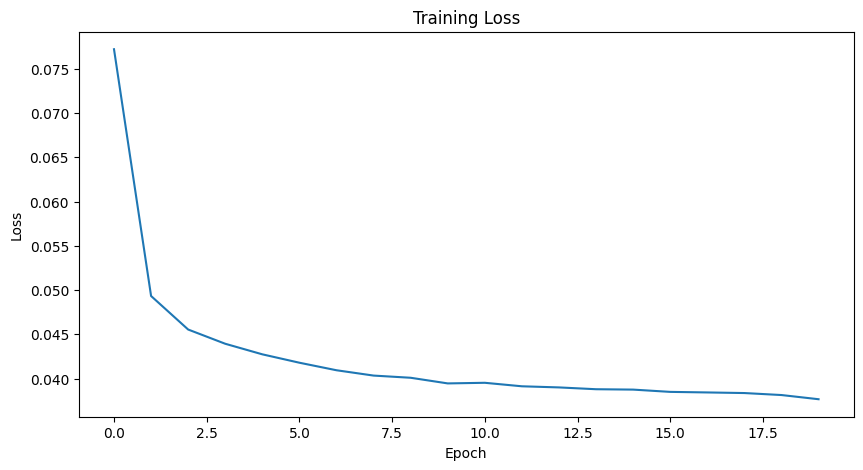

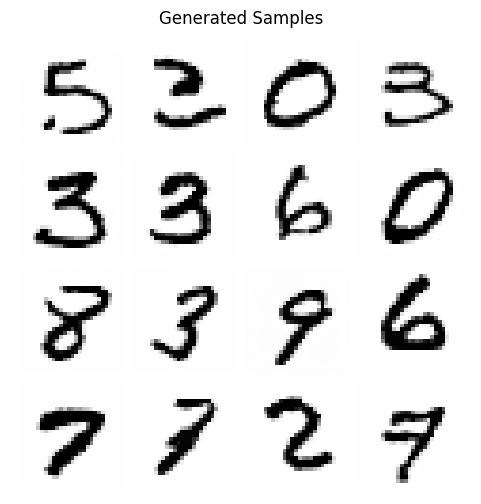

In [ ]:
trainer = DiffusionTrainer(device=device, scheduler_kwargs={
    "beta_schedule": best_params["beta_schedule"],
    "beta_start": best_params["beta_start"],
    "beta_end": best_params["beta_end"],
    "num_train_timesteps": 1000
}, lr=best_params["lr"])
print("Best hyperparameters:", study.best_params)

trainer.train(train_dataloader, epochs=20)

samples = trainer.sample(num_samples=16)
grid = torchvision.utils.make_grid(samples.cpu(), nrow=4)

plt.figure(figsize=(6, 6))
plt.title("Generated Samples")
plt.imshow(grid[0], cmap='Greys')
plt.axis('off')
plt.show()
